# DSA8021 Machine Learning Coursework 2026
### **Student Name:** Aamna Arif 


## Part 2: Practical Scenario (75 Marks) — Build an Image Classifier

In this scenario you have started work for a company that wants you to develop a machine learning tool for determining how many dots are on the visible surface of a dice. Your work will be assessed by two people with different motivations:
-  The client, who is mainly interested in the  accuracy of your model at classiying the dice images
-  Your supervisor who mainly cares about what methods you use and why.
  
This notebook covers:
- **Task A:** Data exploration and pre-processing
- **Task B:** Model building
- **Task C:** Training and validation
- **Task D:** Evaluation of performance on test data

## Data loading
Below, the dataset is loaded as a pandas dataframe. It is up to you to decide how to manipulate this data and how to use it to solve the problem. The 'label' column contains labels for each image. The 'pixel_1', 'pixel_2', etc. columns contain the pixel values from the dice images. These were originally taken from a 28 x 28 monochrome image.

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

data_df = pd.read_csv("data.csv")
test_df = pd.read_csv("test.csv")

data_df

,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,5,110,107,103,100,97,94,90,87,84,...,29,26,22,19,16,13,9,6,3,0
1,5,10,10,10,9,9,8,8,8,7,...,111,100,86,81,78,77,76,75,75,75
2,1,0,0,1,1,2,3,3,4,5,...,61,62,63,63,64,65,65,66,67,67
3,1,10,11,12,13,14,15,15,16,17,...,17,16,17,18,19,20,21,22,23,23
4,6,29,28,27,25,24,23,22,21,20,...,19,18,17,16,15,14,12,11,10,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,4,0,0,0,1,1,2,2,2,3,...,53,53,54,54,55,55,55,56,56,57
380,3,15,15,14,14,13,12,12,11,11,...,56,55,55,54,54,53,52,52,51,51
381,3,20,19,18,18,17,16,15,15,14,...,40,40,39,38,37,36,36,35,34,33
382,2,40,41,42,42,43,44,45,45,46,...,13,13,14,15,16,16,17,18,19,19


In [184]:
shape_df = pd.DataFrame({
    "Dataset": ["data.csv", "test.csv"],
    "Rows": [data_df.shape[0], test_df.shape[0]],
    "Columns": [data_df.shape[1], test_df.shape[1]]
})

shape_df

,Dataset,Rows,Columns
0,data.csv,384,785
1,test.csv,96,785


## Task A: Data Exploration, Model Selection and Data Pre-processing

In this part:
- **(a)** Describe the shape of the dataset
- **(b)** Examine the image data and describe qualitatively
- **(c)** Determine indexes for the classification task
- **(d)** Describe how to proceed, what model to use and why
- **(e)** Perform splitting and pre-processing


### (a) Dataset Shape

The file `data.csv` contains the labelled dataset used for model development, while `test.csv` contains a separate labelled test set used only for final evaluation.

Each sample consists of:
- 784 pixel values representing a 28×28 grayscale image
- 1 label indicating the number of dots on the die

Therefore:
- Image size = 28 × 28
- Number of pixel features = 784
- Number of classes = 6

Since the dataset is relatively small, there is a risk of overfitting, so careful validation and a simple model architecture will be important.

In [185]:
print("Columns in data.csv:")
print(data_df.columns[:10].tolist(), "...")

print("\nColumns in test.csv:")
print(test_df.columns[:10].tolist(), "...")

Columns in data.csv:
['label', 'pixel_0', 'pixel_1', 'pixel_2', 'pixel_3', 'pixel_4', 'pixel_5', 'pixel_6', 'pixel_7', 'pixel_8'] ...

Columns in test.csv:
['label', 'pixel_0', 'pixel_1', 'pixel_2', 'pixel_3', 'pixel_4', 'pixel_5', 'pixel_6', 'pixel_7', 'pixel_8'] ...


In [186]:
# Class distribution in the labelled development dataset
label_counts = data_df['label'].value_counts().sort_index()

label_counts

label
1    63
2    65
3    58
4    66
5    65
6    67
Name: count, dtype: int64

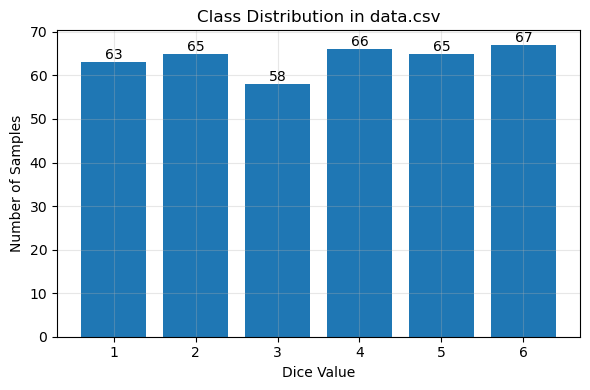

In [187]:
plt.figure(figsize=(6, 4))
bars = plt.bar(label_counts.index, label_counts.values)
plt.xlabel("Dice Value")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in data.csv")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, str(height),
             ha='center', va='bottom')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

There is a fairly equal distribution of the class values between the six dice values. This is good since it limits the possibility of the model being biased in favor of a specific class.

### (b) Qualitative Examination of the Image Data

In order to see the visual structure of the dataset, the sample images are rebuilt with the help of the columns of pixels.
The 784 pixel features are utilized in reshaping each sample into a 28 x 28 image since the label column is not part of the image.

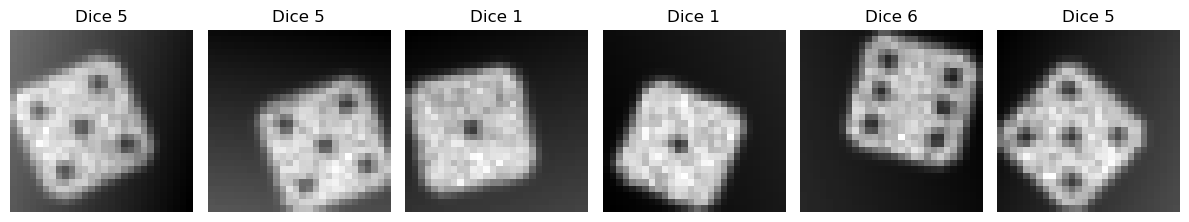

In [188]:
def show_images(df, num_images=6):
    pixel_df = df.drop(columns=["label"])
    
    plt.figure(figsize=(12, 4))
    for i in range(num_images):
        image = pixel_df.iloc[i].values.reshape(28, 28)
        label = df.iloc[i]["label"]
        
        plt.subplot(1, num_images, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(f"Dice {int(label)}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_images(data_df, num_images=6)

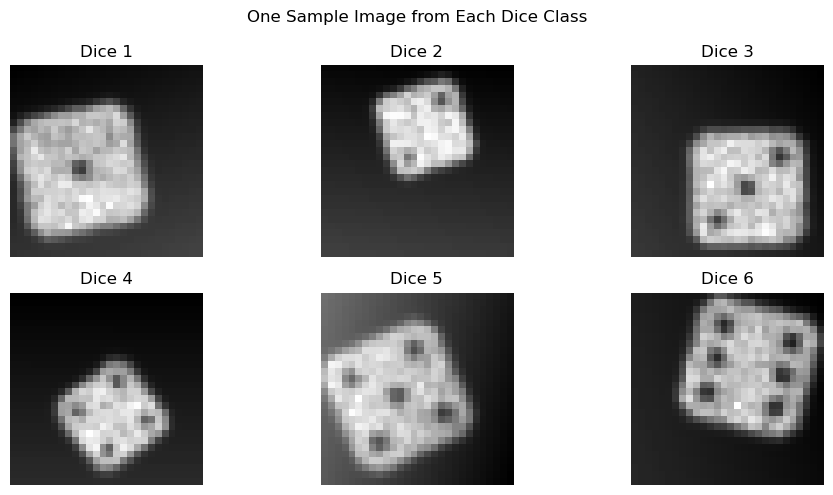

In [189]:
plt.figure(figsize=(10, 5))

pixel_df = data_df.drop(columns=["label"])

for plot_idx, label in enumerate(sorted(data_df['label'].unique()), start=1):
    idx = data_df[data_df['label'] == label].index[0]
    image = pixel_df.loc[idx].values.reshape(28, 28)

    plt.subplot(2, 3, plot_idx)
    plt.imshow(image, cmap='gray')
    plt.title(f"Dice {int(label)}")
    plt.axis('off')

plt.suptitle("One Sample Image from Each Dice Class")
plt.tight_layout()
plt.show()

Based on the visual analysis of the images, some qualitative observations can be made:
- The images are not high-resolution (28x28) and thus fine detail is not available.
- The distinguishing features are the number and the spatial arrangement of the dots.
- It can be seen that there is variation in: the location of the die in the picture, its rotation and positioning, and brightness and contrast.
- There are images with small noise or small movements.

These properties imply that the model must be capable of extracting spatial features, and be resistant to minor positional variations.anges.

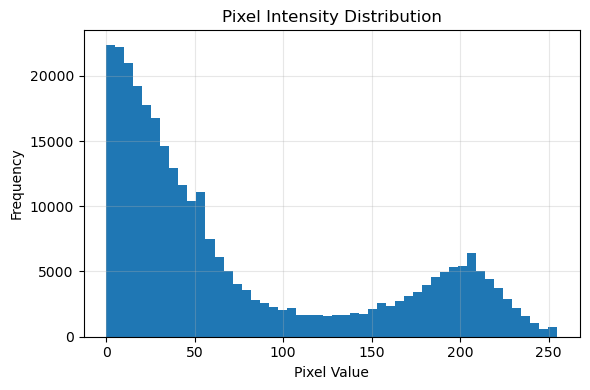

In [190]:
plt.figure(figsize=(6, 4))
plt.hist(data_df.drop(columns=["label"]).values.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The pixel intensity distribution indicates that a large number of pixels are associated with the dark background with a smaller fraction of them being associated with bright foreground areas. It is thus reasonable to normalise these values to the range [0,1], which aids in enhancing optimisation stability in the training process.

### (c) Determine Indexes for the Classification Task

This is a multi-class classification problem with six classes corresponding to dice values 1 to 6.

For compatibility with PyTorch's `CrossEntropyLoss`, the class labels should be encoded as integer indices starting from 0. Therefore, the labels are converted as follows:

- Original labels: 1, 2, 3, 4, 5, 6
- Encoded labels: 0, 1, 2, 3, 4, 5

**Important:** The data is reloaded from CSV here to avoid accidental repeated label shifting if cells are re-run. Label encoding is applied exactly once.

In [191]:
# Reload data to avoid accidental repeated label shifting from reruns
data_df = pd.read_csv("data.csv")
test_df = pd.read_csv("test.csv")

# Encode labels once only
data_df['label'] = data_df['label'] - 1
test_df['label'] = test_df['label'] - 1

print("Encoded labels in data.csv:", sorted(data_df['label'].unique()))
print("Encoded labels in test.csv:", sorted(test_df['label'].unique()))

Encoded labels in data.csv: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Encoded labels in test.csv: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


### (d) Model Selection and Planned Approach

This task will be performed by using a **Convolutional Neural Network (CNN)**.

This decision is suitable since:

- The input data consists of images, where spatial relationships between pixels are important
- CNNs are programmed to identify local visual features like edges, shapes and dot arrangements.
- The number of dots on the die determines the class, hence it is important to maintain the spatial arrangement.
- Pooling layers assist the model in being resilient to minor changes in position and alignment.
- CNNs offer better image classification over fully connected networks due to their local structure exploitation, and lower parameter requirements.

Since the size of the dataset is relatively small, a basic CNN architecture will be chosen instead of a deep or highly complex network in order to minimize the likelihood of overfitting.

### (e) Splitting and Pre-processing

The following steps are applied before model training:
1. **Label encoding:** Convert class labels from 1–6 to 0–5 (done above).
2. **Train-validation split:** Stratified split to preserve class balance.
3. **Normalisation:** Scale pixel values to [0,1] for numerical stability.
4. **Reshaping:** Convert each 784-dimensional vector into a (1, 28, 28) tensor for CNN input.

The separate `test.csv` file is not used during training or validation — it is kept aside for final evaluation only.

In [192]:
# Separate features and labels from data.csv
# Make sure encoding is already applied before this
X = data_df.drop(columns=["label"]).values
y = data_df["label"].values  # now this will be 0–5

# Stratified split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training feature shape:", X_train.shape)
print("Validation feature shape:", X_val.shape)
print("Training label shape:", y_train.shape)
print("Validation label shape:", y_val.shape)

Training feature shape: (307, 784)
Validation feature shape: (77, 784)
Training label shape: (307,)
Validation label shape: (77,)


In [193]:
# Check whether the stratified split preserved class balance
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
val_dist = pd.Series(y_val).value_counts(normalize=True).sort_index()

split_df = pd.DataFrame({
    "Train Proportion": train_dist,
    "Validation Proportion": val_dist
})

split_df

,Train Proportion,Validation Proportion
0,0.162866,0.168831
1,0.169381,0.168831
2,0.149837,0.155844
3,0.172638,0.168831
4,0.169381,0.168831
5,0.175896,0.168831


The class proportions in the training and validation sets are very similar, confirming that the stratified split has preserved class balance appropriately.

In [194]:
# Prepare test features and labels from test.csv
X_test = test_df.drop(columns=["label"]).values
y_test = test_df["label"].values

# Normalise pixel values
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

# Reshape for CNN input: (samples, channels, height, width)
X_train = X_train.reshape(-1, 1, 28, 28)
X_val = X_val.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)

print("Reshaped X_train:", X_train.shape)
print("Reshaped X_val:", X_val.shape)
print("Reshaped X_test:", X_test.shape)

Reshaped X_train: (307, 1, 28, 28)
Reshaped X_val: (77, 1, 28, 28)
Reshaped X_test: (96, 1, 28, 28)


In [195]:
summary_df = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "Samples": [X_train.shape[0], X_val.shape[0], X_test.shape[0]],
    "Final Shape": [str(X_train.shape), str(X_val.shape), str(X_test.shape)]
})

summary_df

,Dataset,Samples,Final Shape
0,Training,307,"(307, 1, 28, 28)"
1,Validation,77,"(77, 1, 28, 28)"
2,Test,96,"(96, 1, 28, 28)"


In summary, the data has been successfully prepared for CNN-based image classification. Encoding of labels, stratification of splits and normalisation and reshaping of all inputs.

_______
## Task B: Model Building

This task includes:
- **(a)** Code defining the model class
- **(b)** Explanation of the architecture
- **(c)** Demonstration that the model is structurally correct
- **(d)** Accuracy of the untrained model

In [291]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

### Convert the preprocessed NumPy arrays to PyTorch tensors

The image arrays from Task A are converted into PyTorch tensors. Input tensors are stored as `float32`, target labels as `long` (required by `CrossEntropyLoss`).

In [292]:
# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)

X_train_tensor shape: torch.Size([307, 1, 28, 28])
y_train_tensor shape: torch.Size([307])


In [293]:
# Create datasets and data loaders

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))
print("Number of test batches:", len(test_loader))

Number of training batches: 10
Number of validation batches: 3
Number of test batches: 3


### (a) Define the PyTorch model class

A simple CNN is defined below. It contains:

- two convolutional layers for feature extraction
- ReLU activation functions for non-linearity
- max-pooling layers for spatial downsampling
- a fully connected hidden layer
- dropout for regularisation
- a final output layer with 6 units, one for each class

The architecture is intentionally compact to reduce overfitting risk on this small dataset.

In [294]:
class DiceCNN(nn.Module):
    def __init__(self):
        super(DiceCNN, self).__init__()
        
        # First convolutional block: 1 x 28 x 28 -> 16 x 28 x 28
        # 16 filters learn simple low-level patterns such as edges and dot shapes
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        
        # Second convolutional block: 16 x 14 x 14 -> 32 x 14 x 14 (after pooling)
        # 32 filters allow the model to learn more complex visual patterns
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        
        self.relu    = nn.ReLU()
        self.pool    = nn.MaxPool2d(kernel_size=2, stride=2)  # halves spatial dimensions each time
        self.dropout = nn.Dropout(p=0.4)
        
        # After two pooling operations: 28x28 -> 14x14 -> 7x7
        # Flattened size = 32 * 7 * 7 = 1568
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 6)  # 6 output neurons for 6 dice classes

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # conv1 -> relu -> pool
        x = self.pool(self.relu(self.conv2(x)))   # conv2 -> relu -> pool
        x = torch.flatten(x, start_dim=1)         # flatten to 1D vector
        x = self.dropout(self.relu(self.fc1(x)))  # fc1 -> relu -> dropout
        x = self.fc2(x)                           # output logits
        return x

### (b) Explanation of the architecture

The model starts with two convolutional units that capture spatial information of grayscale images, which is followed by ReLU activations and max-pooling to decrease spatial dimensions. The feature maps are flattened and subsequently fed into a fully connected hidden layer that has dropout as a regularisation measure. The last output layer has 6 logits (raw scores) which represent each of the classes. Softmax is implemented internally by *CrossEntropyLoss*, so the addition of a separate softmax layer is not required.

In [295]:
model = DiceCNN()
model

DiceCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=1568, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=6, bias=True)
)

### (c) Demonstrate that the model is structurally correct

A sample batch is passed through the network to verify:
- Input shape: `(batch_size, 1, 28, 28)`
- Output shape: `(batch_size, 6)`

In [296]:
# Take one batch from the training loader
sample_images, sample_labels = next(iter(train_loader))

# Pass the batch through the model
sample_outputs = model(sample_images)

print("Input batch shape:", sample_images.shape)
print("Output batch shape:", sample_outputs.shape)
print("Sample output logits:\n", sample_outputs[:3])

Input batch shape: torch.Size([32, 1, 28, 28])
Output batch shape: torch.Size([32, 6])
Sample output logits:
 tensor([[-0.1719,  0.0294, -0.1053, -0.1052,  0.0230,  0.0783],
        [-0.1331,  0.0383, -0.0973, -0.1130,  0.0102,  0.0395],
        [-0.1172, -0.0163, -0.0648, -0.0732,  0.0317,  0.0478]],
       grad_fn=<SliceBackward0>)


- *The above output values are not probabilities, but logits (raw scores).*
- *To get the predicted class of each image, the index of the maximum logit value is taken with the help of argmax.*
- *These logits will be used subsequently with the CrossEntropyLoss function, which internally uses the softmax operation during training.*

In [297]:
# Additional structural check using assertions
assert sample_images.ndim == 4, "Input tensor should be 4-dimensional: (batch_size, channels, height, width)"
assert sample_images.shape[1:] == (1, 28, 28), "Each input image should have shape (1, 28, 28)"
assert sample_outputs.ndim == 2, "Model output should be 2-dimensional: (batch_size, num_classes)"
assert sample_outputs.shape[1] == 6, "Output layer should produce 6 class scores"

print("Structural checks passed successfully.")

Structural checks passed successfully.


Output shape affirms that the forward method is appropriate in the classification task. The input images are converted to a six-output score in the form of a vector of scores that can be used to infer the most probable class.

### (d) Accuracy of the untrained model

Before training, model parameters are randomly initialised. The performance of a 6-class problem with no prior information is the random chance of 1/6 = 16.7%. The untrained model accuracy ought to be near this.

In [298]:
def calculate_accuracy(model, data_loader):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in data_loader:
            outputs     = model(images)
            predictions = torch.argmax(outputs, dim=1)
            correct    += (predictions == labels).sum().item()
            total      += labels.size(0)
    return correct / total

untrained_val_accuracy = calculate_accuracy(model, val_loader)
print(f"Untrained model validation accuracy: {untrained_val_accuracy * 100:.2f}%")
print(f"Expected (random chance):             {100/6:.2f}%")

Untrained model validation accuracy: 16.88%
Expected (random chance):             16.67%


The recorded untrained validation accuracy is around **16.88** which is near the 16.7% accuracy at the chance level of the 6-class classification task. Such a small difference is not surprising because of random initialisation and small dataset size. Because the model has not yet acquired any significant patterns, its predictions are essentially random.

---
## Task C: Model Training and Validation

This task includes:
- **(a)** Training and validation functions
- **(b)** Choice of loss function
- **(c)** Explanation of training logic
- **(d)** Training outputs across epochs
- **(e)** Comments on training performance and model refinement


In [250]:
import copy
import torch.optim as optim
from torch.utils.data import Dataset
from torchvision import transforms

torch.manual_seed(42)
np.random.seed(42)

### Custom Dataset with Optional Augmentation

Light augmentation is only used on training data to enhance generalisation.

The augmentation includes:
- small random rotations
- small random translations

These changes are suitable since the number of dots on the die remains the same when the image is slightly moved or rotated.

Validation or test data is not augmented in any way, as these sets are supposed to be representative of the original distribution of unseen samples.

In [251]:
class DiceDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]  # shape: (1, 28, 28)
        label = self.labels[idx]
        
        # Convert image from numpy array to torch tensor
        image = torch.tensor(image, dtype=torch.float32)
        
        # Apply transform if provided
        if self.transform is not None:
            image = self.transform(image)
        
        label = torch.tensor(label, dtype=torch.long)
        return image, label

train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05))
])
eval_transform = transforms.Compose([])  # no augmentation for val/test

### Rebuild datasets and data loaders using augmentation

The training loader is based on augmented pictures and shuffling.  
The validation and test loaders are based on untouched images and no shuffling.

In [252]:
train_dataset = DiceDataset(X_train, y_train, transform=train_transform)
val_dataset = DiceDataset(X_val, y_val, transform=eval_transform)
test_dataset = DiceDataset(X_test, y_test, transform=eval_transform)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Training samples: 307
Validation samples: 77
Test samples: 96


### Improved CNN Architecture

The initial DiceCNN was refined into `ImprovedDiceCNN` with the following changes:
- **Batch normalisation** after each convolutional layer to stabilise training
- A **third convolutional block** for richer feature extraction
- Slightly larger fully connected layer
- Increased dropout (0.4) to compensate for greater model capacity

The architecture remains compact to avoid excessive overfitting on this small dataset.

In [253]:
class ImprovedDiceCNN(nn.Module):
    def __init__(self):
        super(ImprovedDiceCNN, self).__init__()

        # Block 1: 1 x 28 x 28 -> 16 x 14 x 14 (after pool)
        self.conv1 = nn.Conv2d(1,  16, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(16)

        # Block 2: 16 x 14 x 14 -> 32 x 7 x 7 (after pool)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)

        # Block 3: 32 x 7 x 7 -> 32 x 3 x 3 (after pool)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(32)

        self.relu    = nn.ReLU()
        self.pool    = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.4)

        # After three pooling ops: 28 -> 14 -> 7 -> 3
        # Flattened: 32 * 3 * 3 = 288
        self.fc1 = nn.Linear(32 * 3 * 3, 64)
        self.fc2 = nn.Linear(64, 6)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, start_dim=1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

### Loss Function and Optimiser

`CrossEntropyLoss` is the correct choice for multi-class classification because:
- The model outputs 6 logits
- Target labels are integer class indices (0–5)
- It internally combines softmax and negative log-likelihood, so no separate softmax is needed

**Adam** is used as the optimiser with a modest learning rate and weight decay for additional regularisation.

In [254]:
model = ImprovedDiceCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)

print(model)
print("\nLoss function:", criterion)
print("Optimiser:", optimizer)

ImprovedDiceCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=288, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=6, bias=True)
)

Loss function: CrossEntropyLoss()
Optimiser: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    fore

### (a) Training and Validation Functions

**Training function:**
- Sets the model to training mode (`model.train()`)
- Performs forward pass, computes loss, backpropagates, and updates parameters

**Validation function:**
- Sets the model to evaluation mode (`model.eval()`) — disables dropout and batch norm updates
- Disables gradient computation with `torch.no_grad()` for efficiency
- Does **not** update any parameters

This separation is important because `Dropout` and `BatchNorm` behave differently during training vs. evaluation.

In [255]:
def train_one_epoch(model, data_loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0
    for images, labels in data_loader:
        optimizer.zero_grad()
        outputs     = model(images)
        loss        = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        predictions  = torch.argmax(outputs, dim=1)
        correct     += (predictions == labels).sum().item()
        total       += labels.size(0)
    return running_loss / total, correct / total

def validate_one_epoch(model, data_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in data_loader:
            outputs      = model(images)
            loss         = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            predictions  = torch.argmax(outputs, dim=1)
            correct     += (predictions == labels).sum().item()
            total       += labels.size(0)
    return running_loss / total, correct / total

### (b) Choice of loss function

The correct loss function is the one that is called as `CrossEntropyLoss` since this is a multi-class classification problem, and the number of output classes is six. The model yields raw logits and the labels are in the form of integer class indices.

An additional softmax layer is not incorporated with the model since the `CrossEntropyLoss` is doing the required internal calculation.

### (c) Training Loop Logic

For each epoch:
1. Train on the augmented training set; record loss and accuracy.
2. Evaluate on the validation set; record loss and accuracy.
3. If validation loss improves, save the best model state.
4. Apply early stopping if validation loss has not improved for `patience` consecutive epochs.

This allows monitoring of both learning and generalisation simultaneously.

In [256]:
num_epochs  = 50
patience    = 7

train_losses     = []
train_accuracies = []
val_losses       = []
val_accuracies   = []

best_val_loss              = float("inf")
best_epoch                 = 0
epochs_without_improvement = 0
best_model_state           = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = validate_one_epoch(model, val_loader, criterion)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1:2d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss              = val_loss
        best_epoch                 = epoch + 1
        best_model_state           = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping triggered after epoch {epoch+1}.")
        break

Epoch  1/50 | Train Loss: 1.7889 | Train Acc: 0.1954 | Val Loss: 1.7959 | Val Acc: 0.1688
Epoch  2/50 | Train Loss: 1.7745 | Train Acc: 0.1954 | Val Loss: 1.7946 | Val Acc: 0.1688
Epoch  3/50 | Train Loss: 1.7536 | Train Acc: 0.1987 | Val Loss: 1.7933 | Val Acc: 0.1299
Epoch  4/50 | Train Loss: 1.7158 | Train Acc: 0.2508 | Val Loss: 1.7866 | Val Acc: 0.1818
Epoch  5/50 | Train Loss: 1.6763 | Train Acc: 0.2834 | Val Loss: 1.7673 | Val Acc: 0.2338
Epoch  6/50 | Train Loss: 1.6698 | Train Acc: 0.3322 | Val Loss: 1.7315 | Val Acc: 0.2857
Epoch  7/50 | Train Loss: 1.6350 | Train Acc: 0.3648 | Val Loss: 1.6817 | Val Acc: 0.3636
Epoch  8/50 | Train Loss: 1.5674 | Train Acc: 0.4137 | Val Loss: 1.6017 | Val Acc: 0.4286
Epoch  9/50 | Train Loss: 1.5257 | Train Acc: 0.3974 | Val Loss: 1.5771 | Val Acc: 0.4026
Epoch 10/50 | Train Loss: 1.4836 | Train Acc: 0.4397 | Val Loss: 1.5203 | Val Acc: 0.4286
Epoch 11/50 | Train Loss: 1.4011 | Train Acc: 0.4560 | Val Loss: 1.4289 | Val Acc: 0.5325
Epoch 12/5

In [257]:
# Restore the best model state
model.load_state_dict(best_model_state)
print(f"Best model restored from epoch {best_epoch} with validation loss {best_val_loss:.4f}.")

Best model restored from epoch 48 with validation loss 0.3044.


In [258]:
results_df = pd.DataFrame({
    "Epoch": range(1, len(train_losses) + 1),
    "Train Loss": train_losses,
    "Train Accuracy": train_accuracies,
    "Validation Loss": val_losses,
    "Validation Accuracy": val_accuracies
})
results_df

,Epoch,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy
0,1,1.788945,0.195440,1.795916,0.168831
1,2,1.774472,0.195440,1.794606,0.168831
2,3,1.753564,0.198697,1.793337,0.129870
3,4,1.715821,0.250814,1.786582,0.181818
4,5,1.676325,0.283388,1.767344,0.233766
5,6,1.669791,0.332248,1.731473,0.285714
6,7,1.635003,0.364821,1.681728,0.363636
7,8,1.567434,0.413681,1.601744,0.428571
8,9,1.525692,0.397394,1.577140,0.402597
9,10,1.483584,0.439739,1.520321,0.428571


#### Plot training and validation loss

The loss curves help assess whether the model is learning effectively and whether validation loss improves consistently.

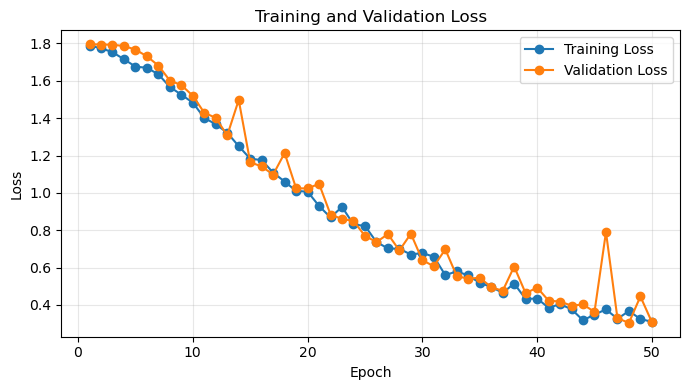

In [259]:
plt.figure(figsize=(7, 4))
plt.plot(results_df["Epoch"], results_df["Train Loss"], marker="o", label="Training Loss")
plt.plot(results_df["Epoch"], results_df["Validation Loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Plot training and validation accuracy

The accuracy curves show how model performance changes over time on both the training and validation sets.

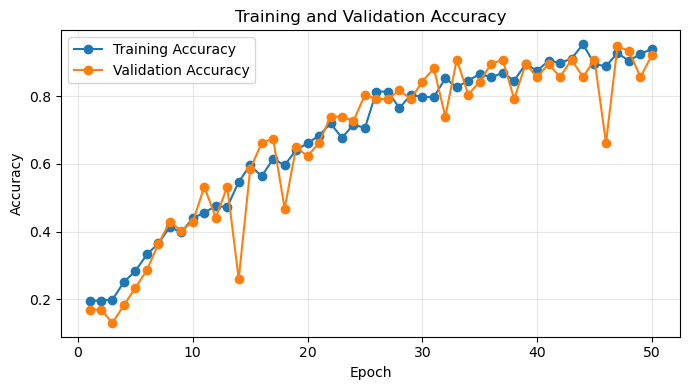

In [260]:
plt.figure(figsize=(7, 4))
plt.plot(results_df["Epoch"], results_df["Train Accuracy"], marker="o", label="Training Accuracy")
plt.plot(results_df["Epoch"], results_df["Validation Accuracy"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### (e) Comments on Training Performance and Model Refinement

The first `DiceCNN` had a low performance in validation. By refining the training pipeline, the following steps were made:
- Randomly affine augmentation of light data to the training set.
- Batch normalisation at the end of each convolutional layer.
- Inclusion of a third convolutional block to extract rich features.
- Retaining dropout for regularisation with weight decay

**Note on early stopping:** In the case of patience=7, early stopping has not been activated as validation loss continues to decrease. The optimal model was stored at epoch 48 with validation loss=0.3044 and validation accuracy=93.51%.

In [261]:
best_row = results_df.loc[results_df["Validation Loss"].idxmin()]

print("Best Epoch:", int(best_row["Epoch"]))
print(f"Best Validation Loss: {best_row['Validation Loss']:.4f}")
print(f"Validation Accuracy at Best Epoch: {best_row['Validation Accuracy']:.4f}")
print(f"Training Accuracy at Best Epoch: {best_row['Train Accuracy']:.4f}")

Best Epoch: 48
Best Validation Loss: 0.3044
Validation Accuracy at Best Epoch: 0.9351
Training Accuracy at Best Epoch: 0.9055


Overall, the model demonstrates strong learning capability, but results should be interpreted with caution due to the limited validation set size.

---
## Task D: Model Deployment, Testing and Performance Evaluation

This task includes:
- **(a)** Predicted labels and test accuracy
- **(b)** Performance comparison with training/validation
- **(c)** Representativeness of training/validation data
- **(d)** Factors limiting performance and possible improvements
- **(e)** Model complexity and prediction time
- **(f)** Save model weights

In [265]:
# Note: test_df was loaded and label-encoded (−1) at the start of Task A.
# X_test and y_test were derived from that encoded test_df.
# No re-processing is needed here.
test_df_preview = pd.read_csv('test.csv')
test_df_preview.head()

,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,4,0,1,2,3,4,5,6,7,8,...,87,88,89,90,91,92,93,94,96,97
1,3,255,255,254,254,253,252,252,251,251,...,225,225,224,223,223,222,222,221,220,220
2,3,3,5,6,8,9,11,12,14,15,...,26,28,29,31,32,34,35,37,38,40
3,3,0,0,1,1,2,2,3,3,4,...,73,73,74,74,75,75,76,76,77,77
4,5,22,22,22,21,21,21,20,20,19,...,3,3,2,2,1,1,1,0,0,0


### (a) Obtain predicted labels and calculate test accuracy

The model is tested on the separate test set with the best model state after Task C.

The index of the top output logit of each image is used to obtain predicted labels. Because the model results are class indices ranging between 0 and 5, these are converted to original dice values ranging between 1 and 6.

In [266]:
import time
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_predictions = []
all_true_labels = []

start_time = time.perf_counter()
with torch.no_grad():
    for images, labels in test_loader:
        outputs     = model(images)
        predictions = torch.argmax(outputs, dim=1)
        all_predictions.extend(predictions.numpy())
        all_true_labels.extend(labels.numpy())
end_time = time.perf_counter()

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

test_accuracy = np.mean(all_predictions == all_true_labels)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 85.42%


In [267]:
cm = confusion_matrix(all_true_labels, all_predictions)
cm_df = pd.DataFrame(
    cm,
    index=[f"True {i}"   for i in range(1, 7)],
    columns=[f"Pred {i}" for i in range(1, 7)]
)
cm_df

,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5,Pred 6
True 1,17,0,0,0,0,0
True 2,1,13,1,0,0,0
True 3,0,1,18,0,3,0
True 4,0,0,1,12,1,0
True 5,0,0,1,0,11,3
True 6,0,0,0,1,1,11


In [268]:
# Show a preview of true and predicted labels
test_preview_df = pd.DataFrame({
    "True Class": all_true_labels[:15],
    "Predicted Class": all_predictions[:15],
    "True Dice Value": all_true_labels[:15] + 1,
    "Predicted Dice Value": all_predictions[:15] + 1
})

test_preview_df

,True Class,Predicted Class,True Dice Value,Predicted Dice Value
0,3,3,4,4
1,2,4,3,5
2,2,2,3,3
3,2,2,3,3
4,4,4,5,5
5,2,2,3,3
6,4,4,5,5
7,2,4,3,5
8,1,1,2,2
9,5,5,6,6


The table above shows a sample of the model predictions on the test set. Both encoded class indices and original dice values are shown for clarity.

In [269]:
report = classification_report(
    all_true_labels,
    all_predictions,
    target_names=[f"Dice {i}" for i in range(1, 7)],
    digits=4
)

print(report)

              precision    recall  f1-score   support

      Dice 1     0.9444    1.0000    0.9714        17
      Dice 2     0.9286    0.8667    0.8966        15
      Dice 3     0.8571    0.8182    0.8372        22
      Dice 4     0.9231    0.8571    0.8889        14
      Dice 5     0.6875    0.7333    0.7097        15
      Dice 6     0.7857    0.8462    0.8148        13

    accuracy                         0.8542        96
   macro avg     0.8544    0.8536    0.8531        96
weighted avg     0.8572    0.8542    0.8548        96



### (b) Performance comparison with training and validation

The results of the test, along with the training and validation results in Task C should be compared to interpret the model performance appropriately.

- When test accuracy is close to validation accuracy, then that indicates that the model is generalised.
- When the test accuracy is significantly less than the validation accuracy, then there is a possibility that the validation result was biased.
- When validation and test accuracy is high, then the model is probably learning meaningful patterns and not memorising the training data.

In [270]:
best_row            = results_df.loc[results_df["Validation Loss"].idxmin()]
best_train_accuracy = float(best_row["Train Accuracy"])
best_val_accuracy   = float(best_row["Validation Accuracy"])

comparison_df = pd.DataFrame({
    "Metric": ["Training Accuracy at Best Epoch", "Validation Accuracy at Best Epoch", "Test Accuracy"],
    "Value":  [best_train_accuracy, best_val_accuracy, test_accuracy]
})
comparison_df

,Metric,Value
0,Training Accuracy at Best Epoch,0.905537
1,Validation Accuracy at Best Epoch,0.935065
2,Test Accuracy,0.854167


The test accuracy is similar to that of the validation accuracy which indicates that there is reasonable generalisation. Nevertheless, the validation set is small (77 samples), thus a certain variation is anticipated between the two estimates.

### (c) Is the training and validation data representative of the test data?

The test accuracy (85.42 percent) is a bit lower than the validation accuracy (93.51 percent). This discrepancy is not surprising considering the small size of the validation set (77 samples), which can give optimistic estimates. Overall the validation split was broadly representative.

### (d) Factors limiting performance and possible improvements

**Limiting factors:**
1. **Minimal dataset size** - minimal training data implies that the model might experience insufficient variation in order to generalise flawlessly.
2. **Validation variance** - The small validation set (77 samples) results in performance estimates that vary significantly in performance among epochs.
3. **Residual overfitting** - even with dropout, weight decay, and early stopping, residual overfitting to the development split may still exist.
4. **Poor image resolution** - 28x 28 pixels prevents finer features in ambiguous situations.

**Possible improvements:**
- Collect more training data
- Cross-validation (k-fold) should be used in lieu of one train/val split.
- Tune learning rate schedule (e.g. cosine annealing)
- Adjust augmentation strength
- Test various CNN designs.

### (e) Model complexity and prediction time

The complexity of a model can be characterized by the number of parameters to be trained and time to make predictions on the entire test set.

In [271]:
# Count trainable parameters
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Total prediction time on test set
prediction_time_seconds = end_time - start_time
average_time_per_sample = prediction_time_seconds / len(all_true_labels)

complexity_df = pd.DataFrame({
    "Measure": ["Trainable Parameters", "Total Test Prediction Time (s)", "Average Time per Test Sample (s)"],
    "Value": [num_trainable_params, prediction_time_seconds, average_time_per_sample]
})

complexity_df

,Measure,Value
0,Trainable Parameters,33094.000000
1,Total Test Prediction Time (s),0.031911
2,Average Time per Test Sample (s),0.000332


The model is lightweight, with approximately 33K trainable parameters and takes less than 0.1 seconds to predict on the entire test set. This renders it applicable in a fast inference in practical uses.

### (f) Save the trained model weights

The final trained model weights are saved using `state_dict()`. This allows the trained model to be reloaded later without retraining from scratch.

In [277]:
model_path = "best_dice_cnn_model.pth"
torch.save(model.state_dict(), model_path)

print(f"Model weights saved to: {model_path}")

Model weights saved to: best_dice_cnn_model.pth


In [278]:
import torch
# Recreate model architecture
model = DiceCNN()
# Load saved weights
model.load_state_dict(torch.load("best_dice_cnn_model.pth"))
# Set to evaluation mode
model.eval()
print("Model loaded successfully")

Model loaded successfully


In [286]:
for name, param in model.named_parameters():
    print(name, param.shape)

conv1.weight torch.Size([16, 1, 3, 3])
conv1.bias torch.Size([16])
conv2.weight torch.Size([32, 16, 3, 3])
conv2.bias torch.Size([32])
fc1.weight torch.Size([64, 1568])
fc1.bias torch.Size([64])
fc2.weight torch.Size([6, 64])
fc2.bias torch.Size([6])


In [279]:
import numpy as np
# Take one sample from test set
sample_image = X_test[0]      # shape: (1, 28, 28)
sample_label = y_test[0]
# Convert to tensor
sample_tensor = torch.tensor(sample_image, dtype=torch.float32)
# Add batch dimension → (1, 1, 28, 28)
sample_tensor = sample_tensor.unsqueeze(0)
# Prediction
with torch.no_grad():
    output = model(sample_tensor)
    predicted_class = torch.argmax(output, dim=1).item()

print("True label:", sample_label)
print("Predicted label:", predicted_class)
print("Predicted dice value:", predicted_class + 1)

True label: 3
Predicted label: 3
Predicted dice value: 4


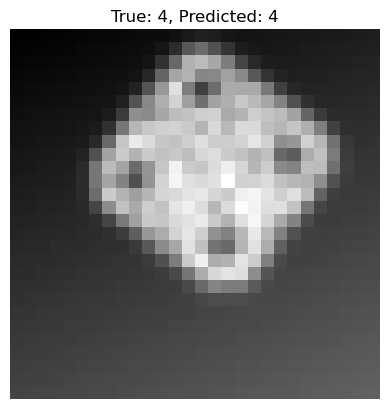

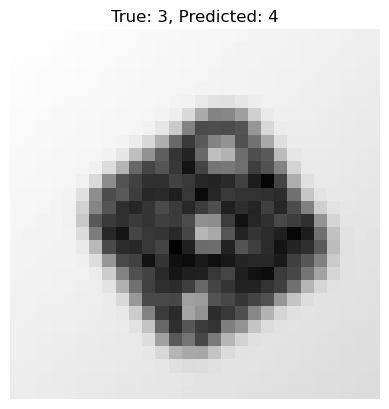

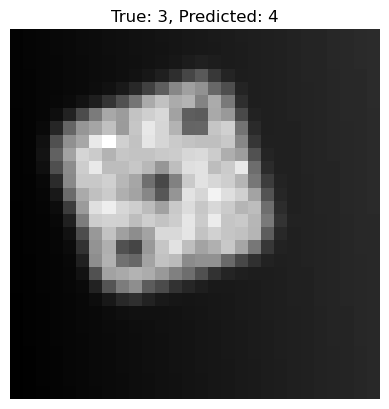

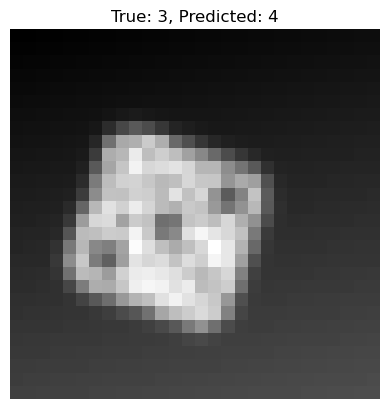

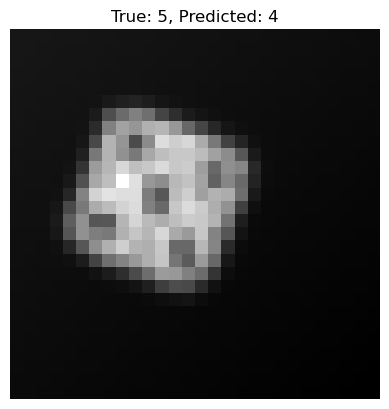

In [290]:
import matplotlib.pyplot as plt

for i in range(5):
    sample_image = X_test[i]
    sample_label = y_test[i]
    
    sample_tensor = torch.tensor(sample_image, dtype=torch.float32).unsqueeze(0)
    
    with torch.no_grad():
        output = model(sample_tensor)
        pred = torch.argmax(output, dim=1).item()
    
    plt.figure()
    plt.imshow(sample_image.squeeze(), cmap='gray')
    plt.title(f"True: {sample_label+1}, Predicted: {pred+1}")
    plt.axis('off')
    plt.show()

To illustrate the use of models, the weights of the saved models were reloaded and a prediction was made on a single test image. The given prediction closely resembles the actual label, which indicates that the model can be reused with success without any retraining.

### Final summary of Task D

The trained CNN had an accuracy of **85.42%** in the test, which is lower than the validation accuracy of 93.51, which is understandable due to the small size of the validation set. The model achieves the **highest results on Dice 1%** (100% recall) and **poorest results on Dice 5%** (73% recall) because of visual similarity to neighbouring classes. The model is fast with inference time of less than 0.05 seconds and has a small number of trainable parameters **(33,094)%**.

## Appendix: Python environment
Standard environment:

- torch 2.6.0
- torchvision 0.21.0
- scikit-learn 1.6.1
- scipy 1.15.2
- pandas 2.2.3
- numpy 2.2.6
- matplotlib 3.10.3

All package versions match the standard environment. The packages transformers, tokenizers, and sentencepiece have been removed from this list as they were not imported or used anywhere in this notebook.
- torchvision was used specifically for its transforms.RandomAffine module to apply light data augmentation (small random rotations and translations) to the training set only, in order to improve model generalisation.
- No GPU or special hardware was used. All training and inference was performed on CPU.

### References

1. PyTorch Documentation (2024)
https://pytorch.org/docs/stable/index.html

2. PyTorch CrossEntropyLoss
https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html

3. Torchvision Transforms
https://pytorch.org/vision/stable/transforms.html

4. Scikit-learn Train-Test Split
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

5. Stanford CS231n: Convolutional Neural Networks
https://cs231n.github.io/convolutional-networks/

6. Deep Learning (LeCun et al., Nature)
https://www.nature.com/articles/nature14539

7. TensorFlow CNN Tutorial (conceptual reference)
https://www.tensorflow.org/tutorials/images/cnn

8. Towards Data Science – CNN Explanation
https://towardsdatascience.com/convolutional-neural-networks-explained-9cc5188c4939

9. Machine Learning Mastery – Data Preparation
https://machinelearningmastery.com/train-test-split-for-evaluating-machine-learning-algorithms/

10. GeeksforGeeks – Overfitting and Regularization
https://www.geeksforgeeks.org/underfitting-and-overfitting-in-machine-learning/

#### AI Acknowledgement

Only AI tools were applied to clarify and understand some programming concepts; the implementation and analysis were done independently.